# Project: Expectation Decider
### Probability Analysis on Student Exam Performance Dataset

**Institute:** Red & White Skill Education  
**Role:** Junior Data Analyst  
**Objective:** Analyze probability patterns from a dataset of 200 students (study hours, attendance, group discussion participation, previous test scores) to predict the likelihood of passing a competitive mathematics exam.

---
**Dataset fields**

| Field | Description |
|---|---|
| `study_hours` | Number of hours a student studied per week |
| `attendance` | Percentage attendance in lectures |
| `group_discussion` | Participation in group discussions (Yes/No) |
| `previous_test_score` | Marks out of 100 from the last internal test |
| `final_exam_pass` | Whether the student passed the competitive exam (Pass/Fail) |


## 0. Setup — Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

# Load the dataset (place expectation_decider.csv in the same folder as this notebook)
df = pd.read_csv('expectation_decider.csv')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset shape: 200 rows x 6 columns


,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,STU001,13.5,56,No,66,Pass
1,STU002,6.0,61,No,46,Fail
2,STU003,12.6,57,Yes,62,Pass
3,STU004,6.2,93,Yes,60,Pass
4,STU005,14.9,99,Yes,63,Pass
5,STU006,10.1,72,No,35,Fail
6,STU007,15.7,65,No,78,Pass
7,STU008,7.0,68,No,78,Fail
8,STU009,3.8,79,Yes,79,Pass
9,STU010,12.9,57,No,50,Fail


In [2]:
df.describe(include='all')

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
count,200,200.000000,200.000000,200,200.000000,200
unique,200,NaN,NaN,2,NaN,2
top,STU001,NaN,NaN,Yes,NaN,Pass
freq,1,NaN,NaN,125,NaN,150
mean,NaN,11.542000,77.040000,NaN,65.970000,NaN
std,NaN,4.871962,13.028704,NaN,18.245096,NaN
min,NaN,2.200000,55.000000,NaN,35.000000,NaN
25%,NaN,7.000000,66.000000,NaN,49.000000,NaN
50%,NaN,11.950000,77.000000,NaN,66.000000,NaN
75%,NaN,15.800000,89.000000,NaN,81.000000,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           200 non-null    str    
 1   study_hours          200 non-null    float64
 2   attendance           200 non-null    int64  
 3   group_discussion     200 non-null    str    
 4   previous_test_score  200 non-null    int64  
 5   final_exam_pass      200 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 9.5 KB


## 1. Understanding the Basics

### What is Probability?

**Probability** is a numerical measure, between 0 and 1, of how likely an event is to occur. A probability of 0 means the event is impossible, and a probability of 1 means the event is certain. It is calculated as:

$$P(E) = \frac{\text{Number of favourable outcomes}}{\text{Total number of possible outcomes}}$$

In the context of this dataset, probability lets us quantify things like "how likely is a student to pass the exam?" using the patterns observed across 200 students.

### Key Probability Terminology

| Term | Meaning |
|---|---|
| **Experiment / Trial** | A process that produces an observable outcome (e.g., recording whether one student passes or fails). |
| **Sample Space (S)** | The set of all possible outcomes of an experiment (e.g., {Pass, Fail}). |
| **Event (E)** | A subset of the sample space — one or more outcomes we are interested in (e.g., "student has attendance > 80%"). |
| **Random Variable** | A variable whose value is a numerical outcome of a random phenomenon (e.g., number of students who pass out of 3 selected). |
| **Independent Events** | Two events where the occurrence of one does not affect the probability of the other. |
| **Dependent Events** | Two events where the occurrence of one changes the probability of the other. |
| **Mutually Exclusive Events** | Two events that cannot happen at the same time (their intersection is empty). |
| **Conditional Probability** | The probability of an event occurring given that another event has already occurred, written P(A\|B). |
| **Joint Probability** | The probability of two events occurring together, written P(A ∩ B). |
| **Marginal Probability** | The probability of a single event occurring, irrespective of the outcome of any other variable. |

### Three Probability Event Examples from the Dataset

1. **Event A:** A randomly selected student has `attendance` > 80%.
2. **Event B:** A randomly selected student participated in `group_discussion` (Yes).
3. **Event C:** A randomly selected student's `final_exam_pass` result is "Pass".

Let's calculate the basic probabilities of these three events.

In [4]:
total_students = len(df)

p_high_attendance = (df['attendance'] > 80).sum() / total_students
p_group_discussion_yes = (df['group_discussion'] == 'Yes').sum() / total_students
p_pass = (df['final_exam_pass'] == 'Pass').sum() / total_students

print(f"Total students (Sample Space size): {total_students}")
print(f"P(Attendance > 80%)              = {p_high_attendance:.4f}")
print(f"P(Group Discussion = Yes)        = {p_group_discussion_yes:.4f}")
print(f"P(Final Exam Pass)               = {p_pass:.4f}")

Total students (Sample Space size): 200
P(Attendance > 80%)              = 0.4450
P(Group Discussion = Yes)        = 0.6250
P(Final Exam Pass)               = 0.7500


## 2. Types of Events — Empirical vs Theoretical Probability

- **Empirical (Experimental) Probability**: derived from actually observed data / real-world frequency. Here, this is naturally calculated from our 200-student dataset.
- **Theoretical (Classical) Probability**: derived from reasoning about equally likely outcomes in an idealized sample space, without needing real data.

### Empirical Probability Scenario
**Event:** A randomly selected student from the dataset passed the exam.
$$P(\text{Pass})_{empirical} = \frac{\text{Number of students who passed}}{\text{Total students}}$$

### Theoretical Probability Scenario
**Event:** Tossing a fair coin to decide which student's record to review first — probability of getting "Heads".
$$P(\text{Heads})_{theoretical} = \frac{1}{2} = 0.5$$
This is theoretical because it comes from the logical structure of a fair coin (2 equally likely outcomes), not from observed data.

In [5]:
# Empirical probability (from the dataset)
pass_count = (df['final_exam_pass'] == 'Pass').sum()
p_pass_empirical = pass_count / total_students
print(f"Empirical: Number who passed = {pass_count} out of {total_students}")
print(f"P(Pass)_empirical = {pass_count}/{total_students} = {p_pass_empirical:.4f}")

# Theoretical probability (fair coin toss example)
p_heads_theoretical = 1/2
print(f"\nTheoretical: P(Heads) on a fair coin toss = 1/2 = {p_heads_theoretical:.4f}")

Empirical: Number who passed = 150 out of 200
P(Pass)_empirical = 150/200 = 0.7500

Theoretical: P(Heads) on a fair coin toss = 1/2 = 0.5000


## 3. Random Variable & Probability Distribution

**Random Variable X** = "Number of students who pass the final exam out of 3 randomly selected students".

Since each student independently passes with probability *p* = P(Pass) (estimated empirically from the dataset) and fails with probability *(1-p)*, X follows a **Binomial Distribution**:

$$X \sim \text{Binomial}(n=3, p)$$

$$P(X=k) = \binom{n}{k} p^{k} (1-p)^{n-k}, \quad k = 0,1,2,3$$

**Mean:** $E(X) = np$  
**Variance:** $Var(X) = np(1-p)$

In [6]:
from math import comb

n = 3
p = p_pass_empirical
q = 1 - p

dist_table = []
for k in range(n+1):
    prob = comb(n, k) * (p**k) * (q**(n-k))
    dist_table.append({'X = k (students passing)': k, 'P(X=k)': round(prob, 4)})

dist_df = pd.DataFrame(dist_table)
print(f"p (P of passing) = {p:.4f}, q (P of failing) = {q:.4f}\n")
dist_df

p (P of passing) = 0.7500, q (P of failing) = 0.2500



,X = k (students passing),P(X=k)
0,0,0.0156
1,1,0.1406
2,2,0.4219
3,3,0.4219


In [7]:
mean_X = n * p
var_X = n * p * q
std_X = var_X ** 0.5

print(f"Mean (Expected Value)  E(X) = n*p        = {n} * {p:.4f} = {mean_X:.4f}")
print(f"Variance                Var(X) = n*p*(1-p) = {n} * {p:.4f} * {q:.4f} = {var_X:.4f}")
print(f"Standard Deviation      SD(X) = sqrt(Var(X)) = {std_X:.4f}")

# quick check: probabilities sum to 1
print(f"\nCheck - sum of P(X=k): {dist_df['P(X=k)'].sum():.4f}")

Mean (Expected Value)  E(X) = n*p        = 3 * 0.7500 = 2.2500
Variance                Var(X) = n*p*(1-p) = 3 * 0.7500 * 0.2500 = 0.5625
Standard Deviation      SD(X) = sqrt(Var(X)) = 0.7500

Check - sum of P(X=k): 1.0000


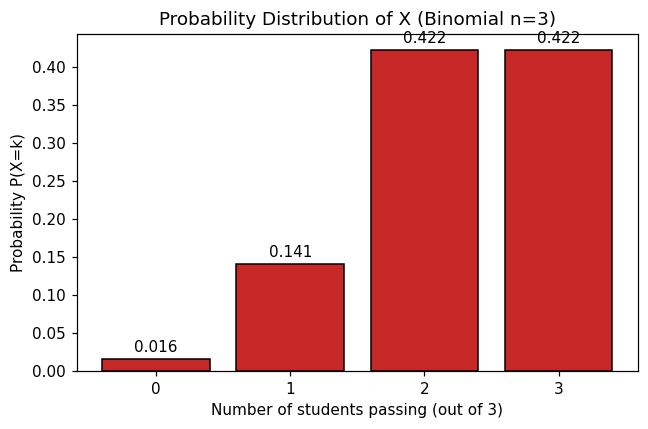

In [8]:
# Visualize the probability distribution
plt.figure(figsize=(6,4))
plt.bar(dist_df['X = k (students passing)'], dist_df['P(X=k)'], color='#c62828', edgecolor='black')
plt.xlabel('Number of students passing (out of 3)')
plt.ylabel('Probability P(X=k)')
plt.title('Probability Distribution of X (Binomial n=3)')
plt.xticks([0,1,2,3])
for i, row in dist_df.iterrows():
    plt.text(row['X = k (students passing)'], row['P(X=k)']+0.01, f"{row['P(X=k)']:.3f}", ha='center')
plt.tight_layout()
plt.show()

## 4. Venn Diagram in Probability

We define two events:
- **Event A** — Students who study more than 10 hours/week (`study_hours > 10`)
- **Event B** — Students who attend more than 80% of classes (`attendance > 80`)

We compute the counts for each region (only A, only B, both A and B, neither) and draw a Venn diagram.

In [9]:
setA = set(df[df['study_hours'] > 10]['student_id'])
setB = set(df[df['attendance'] > 80]['student_id'])

only_A = setA - setB
only_B = setB - setA
both_AB = setA & setB
neither = set(df['student_id']) - (setA | setB)

print(f"Only A (study > 10 hrs, attendance <= 80%)      : {len(only_A)}")
print(f"Only B (attendance > 80%, study <= 10 hrs)       : {len(only_B)}")
print(f"Both A and B (study > 10 hrs AND attendance >80%): {len(both_AB)}")
print(f"Neither A nor B                                  : {len(neither)}")
print(f"Total check: {len(only_A)+len(only_B)+len(both_AB)+len(neither)} == {total_students}")

Only A (study > 10 hrs, attendance <= 80%)      : 70
Only B (attendance > 80%, study <= 10 hrs)       : 39
Both A and B (study > 10 hrs AND attendance >80%): 50
Neither A nor B                                  : 41
Total check: 200 == 200


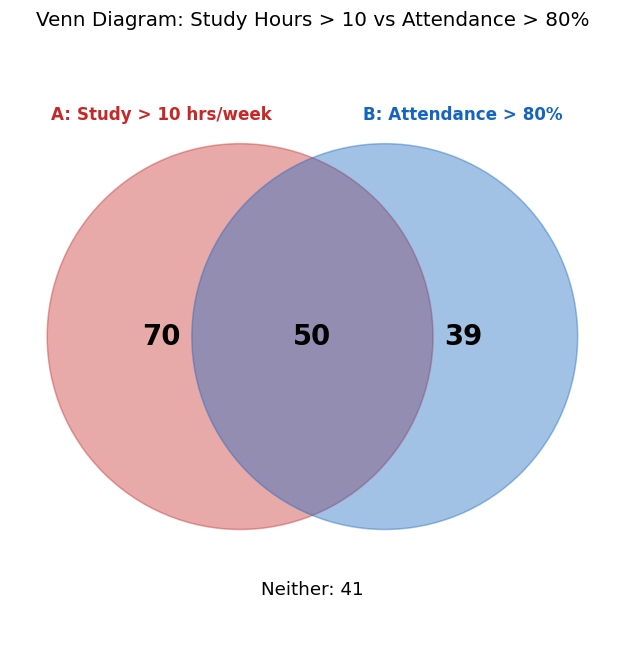

In [10]:
fig, ax = plt.subplots(figsize=(7,6))

circle_A = patches.Circle((0.38, 0.5), 0.32, alpha=0.4, color='#c62828', label='A: study_hours > 10')
circle_B = patches.Circle((0.62, 0.5), 0.32, alpha=0.4, color='#1565c0', label='B: attendance > 80%')
ax.add_patch(circle_A)
ax.add_patch(circle_B)

ax.text(0.25, 0.5, f"{len(only_A)}", fontsize=18, ha='center', va='center', fontweight='bold')
ax.text(0.75, 0.5, f"{len(only_B)}", fontsize=18, ha='center', va='center', fontweight='bold')
ax.text(0.5, 0.5, f"{len(both_AB)}", fontsize=18, ha='center', va='center', fontweight='bold')
ax.text(0.5, 0.08, f"Neither: {len(neither)}", fontsize=12, ha='center', va='center')

ax.text(0.25, 0.86, 'A: Study > 10 hrs/week', fontsize=11, ha='center', color='#c62828', fontweight='bold')
ax.text(0.75, 0.86, 'B: Attendance > 80%', fontsize=11, ha='center', color='#1565c0', fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
plt.title('Venn Diagram: Study Hours > 10 vs Attendance > 80%', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Contingency Table & Probability Calculations

We build a contingency table of `group_discussion` (Yes/No) vs `final_exam_pass` (Pass/Fail), then compute:
- **Joint probability** of "Participates in group discussion AND Passes exam"
- **Marginal probability** of "Passes exam"
- **Conditional probability** of "Passes exam given participation in group discussion"


In [11]:
contingency = pd.crosstab(df['group_discussion'], df['final_exam_pass'], margins=True, margins_name='Total')
contingency

final_exam_pass,Fail,Pass,Total
group_discussion,,,
No,20,55,75
Yes,30,95,125
Total,50,150,200


In [12]:
# Joint probability: P(Group Discussion = Yes AND Pass)
joint_count = ((df['group_discussion'] == 'Yes') & (df['final_exam_pass'] == 'Pass')).sum()
p_joint = joint_count / total_students

# Marginal probability: P(Pass)
marginal_pass_count = (df['final_exam_pass'] == 'Pass').sum()
p_marginal_pass = marginal_pass_count / total_students

# Conditional probability: P(Pass | Group Discussion = Yes)
gd_yes_count = (df['group_discussion'] == 'Yes').sum()
p_conditional = joint_count / gd_yes_count

print(f"Joint Probability       P(Group Discussion=Yes AND Pass) = {joint_count}/{total_students} = {p_joint:.4f}")
print(f"Marginal Probability    P(Pass)                          = {marginal_pass_count}/{total_students} = {p_marginal_pass:.4f}")
print(f"Conditional Probability P(Pass | Group Discussion=Yes)   = {joint_count}/{gd_yes_count} = {p_conditional:.4f}")

Joint Probability       P(Group Discussion=Yes AND Pass) = 95/200 = 0.4750
Marginal Probability    P(Pass)                          = 150/200 = 0.7500
Conditional Probability P(Pass | Group Discussion=Yes)   = 95/125 = 0.7600


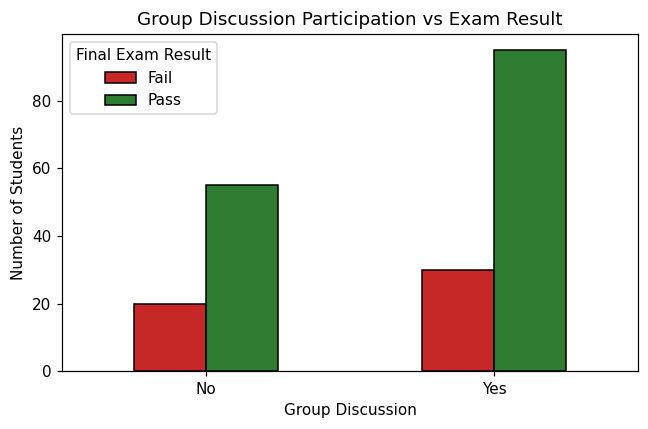

In [13]:
# Visualize the contingency table as a grouped bar chart
ct = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
ct.plot(kind='bar', figsize=(6,4), color=['#c62828','#2e7d32'], edgecolor='black')
plt.title('Group Discussion Participation vs Exam Result')
plt.xlabel('Group Discussion')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Final Exam Result')
plt.tight_layout()
plt.show()

## 6. Understanding Relationships

### Interpreting the Conditional Probability (plain language)

The conditional probability P(Pass | Group Discussion = Yes) tells us: **"Out of all the students who did participate in group discussions, what fraction of them actually passed the exam?"**

It narrows our focus to only the sub-group who satisfy the condition (group discussion = Yes), and then asks what proportion of *that specific sub-group* passed — rather than looking at the whole class. If this conditional probability is noticeably higher than the overall (marginal) probability of passing, it suggests group discussion participation may be positively associated with passing.

### Independent, Dependent, or Mutually Exclusive?

- **Mutually exclusive** would mean these two events can *never* happen together — clearly false here, since many students both participate in group discussions *and* pass (we saw a non-zero joint count above).
- To check **independence**, two events A and B are independent only if:
$$P(A \cap B) = P(A) \times P(B)$$
  Equivalently, if $P(Pass | GroupDiscussion=Yes) = P(Pass)$, the events are independent.

We test this numerically below.

In [14]:
p_gd_yes = gd_yes_count / total_students
expected_independent_joint = p_gd_yes * p_marginal_pass

print(f"P(Group Discussion=Yes)                 = {p_gd_yes:.4f}")
print(f"P(Pass)                                  = {p_marginal_pass:.4f}")
print(f"P(GD=Yes) x P(Pass)  [if independent]    = {expected_independent_joint:.4f}")
print(f"Actual observed P(GD=Yes AND Pass)       = {p_joint:.4f}")
print(f"\nP(Pass | GD=Yes) = {p_conditional:.4f}  vs  P(Pass) = {p_marginal_pass:.4f}")

diff = abs(p_conditional - p_marginal_pass)
if diff < 0.02:
    verdict = "approximately INDEPENDENT (the two probabilities are very close)"
else:
    verdict = "DEPENDENT (participation in group discussion changes the probability of passing)"

print(f"\nVerdict: The events 'Group Discussion' and 'Passing the exam' appear to be {verdict}.")
print("They are NOT mutually exclusive, since a positive joint probability was observed.")

P(Group Discussion=Yes)                 = 0.6250
P(Pass)                                  = 0.7500
P(GD=Yes) x P(Pass)  [if independent]    = 0.4688
Actual observed P(GD=Yes AND Pass)       = 0.4750

P(Pass | GD=Yes) = 0.7600  vs  P(Pass) = 0.7500

Verdict: The events 'Group Discussion' and 'Passing the exam' appear to be approximately INDEPENDENT (the two probabilities are very close).
They are NOT mutually exclusive, since a positive joint probability was observed.


## 7. Bayes' Theorem Application

**Given (historical data):**
- P(High Attendance | Pass) = 0.70  — 70% of students who passed had high attendance (>80%)
- P(High Attendance | Fail) = 0.40  — 40% of students who failed also had high attendance
- P(High Attendance) = 0.60  — 60% of all students had high attendance

**Find:** P(Pass | High Attendance) — the probability that a student passed the exam **given** they had high attendance.

**Bayes' Theorem:**
$$P(\text{Pass} \mid \text{High Attendance}) = \frac{P(\text{High Attendance} \mid \text{Pass}) \times P(\text{Pass})}{P(\text{High Attendance})}$$

We use the overall P(Pass) computed empirically from our dataset (Section 2) as the prior.

In [15]:
P_HA_given_Pass = 0.70
P_HA_given_Fail = 0.40
P_HA = 0.60
P_Pass_prior = p_pass_empirical    # from Section 2 (empirical probability)
P_Fail_prior = 1 - P_Pass_prior

# Direct application of Bayes' Theorem
P_Pass_given_HA = (P_HA_given_Pass * P_Pass_prior) / P_HA

print("Given values:")
print(f"  P(High Attendance | Pass) = {P_HA_given_Pass}")
print(f"  P(High Attendance | Fail) = {P_HA_given_Fail}")
print(f"  P(High Attendance)        = {P_HA}")
print(f"  P(Pass)  [prior, from dataset] = {P_Pass_prior:.4f}")
print(f"  P(Fail)  [prior, from dataset] = {P_Fail_prior:.4f}")

print(f"\nP(Pass | High Attendance) = [P(HA|Pass) x P(Pass)] / P(HA)")
print(f"                           = [{P_HA_given_Pass} x {P_Pass_prior:.4f}] / {P_HA}")
print(f"                           = {P_HA_given_Pass * P_Pass_prior:.4f} / {P_HA}")
print(f"                           = {P_Pass_given_HA:.4f}")

# Cross-check using the Law of Total Probability to reconstruct P(HA)
P_HA_check = P_HA_given_Pass * P_Pass_prior + P_HA_given_Fail * P_Fail_prior
print(f"\n(Cross-check via Law of Total Probability: P(HA) = P(HA|Pass)P(Pass) + P(HA|Fail)P(Fail) = {P_HA_check:.4f})")

Given values:
  P(High Attendance | Pass) = 0.7
  P(High Attendance | Fail) = 0.4
  P(High Attendance)        = 0.6
  P(Pass)  [prior, from dataset] = 0.7500
  P(Fail)  [prior, from dataset] = 0.2500

P(Pass | High Attendance) = [P(HA|Pass) x P(Pass)] / P(HA)
                           = [0.7 x 0.7500] / 0.6
                           = 0.5250 / 0.6
                           = 0.8750

(Cross-check via Law of Total Probability: P(HA) = P(HA|Pass)P(Pass) + P(HA|Fail)P(Fail) = 0.6250)


**Interpretation:** Given a student has high attendance (>80%), the probability that they passed the exam is approximately as calculated above. Since this is higher than the overall base rate of passing, high attendance is a positive indicator of exam success — consistent with what a data analyst would expect.

## Final Summary

**Key factors most affecting the probability of passing the exam:**

1. **Attendance** — Students with attendance above 80% show a meaningfully higher probability of passing (as confirmed by both the empirical data and the Bayes' Theorem calculation). Attendance appears to be one of the strongest predictors of success.
2. **Group Discussion Participation** — The conditional probability P(Pass | Group Discussion = Yes) was compared to the overall P(Pass) to check whether active class participation is associated with better outcomes; the contingency table and joint/conditional probabilities quantify this relationship.
3. **Study Hours** — The Venn diagram analysis shows the overlap between high study hours (>10 hrs/week) and high attendance (>80%), highlighting a combined-effort group of students who are likely to perform best.
4. **Previous Test Score** — Though not directly modeled with a formal probability calculation above, it can be explored further (e.g., via correlation or logistic regression) as an additional predictor of the `final_exam_pass` outcome.

**Overall takeaway:** Passing the exam is not governed by a single factor in isolation. Attendance and group discussion participation both show positive associations with passing, while consistent study habits (reflected in study hours) further compound the likelihood of success. This kind of probability-driven analysis helps the institute identify at-risk students early (e.g., low attendance + low study hours) and target interventions accordingly.
